- Task 5D By Nabankur Ray

# Loading the "MINIST" Digit Datasets

In [30]:
# Importing Required Libraries

import numpy as np                      # For numerical operations and array handling
from keras.datasets import mnist        # To load the MNIST handwritten digits dataset
import matplotlib.pyplot as plt         # For plotting and visualizing data
from keras.models import Sequential     # For building a sequential (layer-by-layer) neural network model
from keras.layers import Dense, Flatten # Dense: fully connected layers; Flatten: convert 2D images to 1D vectors
from keras.utils import to_categorical  # For one-hot encoding of labels

In [31]:
# Load training and test data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [32]:
# Display the size of Training Data & Test Data
print("Training set size:")
print("Images:", x_train.shape)
print("Labels:", y_train.shape)

print("\nTest set size:")
print("Images:", x_test.shape)
print("Labels:", y_test.shape)

Training set size:
Images: (60000, 28, 28)
Labels: (60000,)

Test set size:
Images: (10000, 28, 28)
Labels: (10000,)


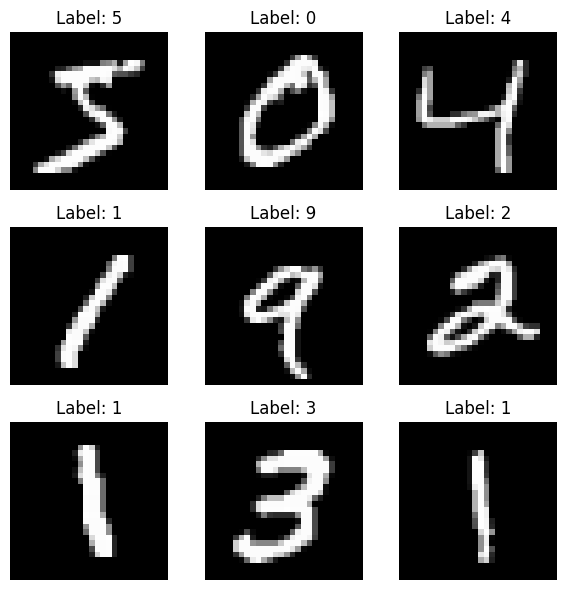

In [33]:
# Display first 9 images from training set
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [34]:
# count the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ")
dict(zip(unique, counts))

Train labels: 


{np.uint8(0): np.int64(5923),
 np.uint8(1): np.int64(6742),
 np.uint8(2): np.int64(5958),
 np.uint8(3): np.int64(6131),
 np.uint8(4): np.int64(5842),
 np.uint8(5): np.int64(5421),
 np.uint8(6): np.int64(5918),
 np.uint8(7): np.int64(6265),
 np.uint8(8): np.int64(5851),
 np.uint8(9): np.int64(5949)}

# Data Preprocess

In [35]:
# Normalize the image pixel values (0–255 to 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Display the size of Training Data & Test Data after Normalizing
print("Training set size:")
print("Images:", x_train.shape)
print("Labels:", y_train.shape)

print("\nTest set size:")
print("Images:", x_test.shape)
print("Labels:", y_test.shape)

Training set size:
Images: (60000, 28, 28)
Labels: (60000,)

Test set size:
Images: (10000, 28, 28)
Labels: (10000,)


In [36]:
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [37]:
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build One Hidden Layer MLP Model

In [38]:
# Build a simple MLP model with one hidden layer
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))  # One hidden layer with 128 units
model.add(Dense(10, activation='softmax'))                    # Output layer for 10 digits

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=2)

Epoch 1/5
469/469 - 2s - 5ms/step - accuracy: 0.8987 - loss: 0.3677
Epoch 2/5
469/469 - 2s - 5ms/step - accuracy: 0.9532 - loss: 0.1653
Epoch 3/5
469/469 - 3s - 6ms/step - accuracy: 0.9643 - loss: 0.1207
Epoch 4/5
469/469 - 3s - 7ms/step - accuracy: 0.9733 - loss: 0.0933
Epoch 5/5
469/469 - 2s - 4ms/step - accuracy: 0.9787 - loss: 0.0756


In [39]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\n >>> Test Accuracy: {test_accuracy:.4f}")


 >>> Test Accuracy: 0.9724


One-hidden-layer MLP with 128 units reached **97.24% test accuracy**, that means the model correctly classified 97.24% of unseen digit images after 5 epochs, which is a solid baseline for MNIST.

# Vary Number of Hidden Layers

**Multi-Layer Perceptron (MLP) Model with different number of Hidden-layers**

Setting the no. of Hidden Layer - [2, 4, 6, 8, 10]

In [45]:
# List of number of hidden layers to test
hidden_layers_list = [2, 4, 6, 8, 10]
accuracies = []

for n_layers in hidden_layers_list:
    # Build model
    model = Sequential()
    model.add(Dense(100, activation='relu', input_shape=(784,)))  # First hidden layer

    for _ in range(n_layers - 1):
        model.add(Dense(100, activation='relu'))  # Additional hidden layers

    model.add(Dense(10, activation='softmax'))  # Output layer

    # Compile and train
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

    # Evaluate
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(test_acc)
    print(f"No. of Hidden Layers: {n_layers} → Test Accuracy: {test_acc:.4f}")

No. of Hidden Layers: 2 → Test Accuracy: 0.9739
No. of Hidden Layers: 4 → Test Accuracy: 0.9743
No. of Hidden Layers: 6 → Test Accuracy: 0.9746
No. of Hidden Layers: 8 → Test Accuracy: 0.9686
No. of Hidden Layers: 10 → Test Accuracy: 0.9709


**OBSERVATIONS**

* Performance is fairly stable for 2–6 layers, with a small peak at 6 layers.

* Adding more than 6 layers shows a slight drop in test accuracy, possibly due to overfitting or training difficulties

# Vary Hidden Layer Size

Multi-Layer Perceptron (MLP) Model with different sizes of Single Hidden-layer

In [46]:
# Size of the Hidden Layer
hidden_layer_sizes = [50, 100, 150, 200]
accuracies = []

for size in hidden_layer_sizes:
    # Build model
    model = Sequential()
    model.add(Dense(size, activation='relu', input_shape=(784,)))
    model.add(Dense(size, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    # Compile and train
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

    # Evaluate
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(test_acc)
    print(f"Single Hidden Layer with Size: {size} → Test Accuracy: {test_acc:.4f}")


Single Hidden Layer with Size: 50 → Test Accuracy: 0.9625
Single Hidden Layer with Size: 100 → Test Accuracy: 0.9752
Single Hidden Layer with Size: 150 → Test Accuracy: 0.9728
Single Hidden Layer with Size: 200 → Test Accuracy: 0.9779


**INSIGHTS**

* Increasing hidden layer size generally improves accuracy, with the highest score at 200 neurons.

* Performance jumps notably between 50 and 100 neurons, then stabilizes.

* Larger hidden layers likely capture more complex patterns but also increase the risk of overfitting for small datasets.

# Double Descent

Double descent is a modern phenomenon in machine learning where increasing model complexity does not simply follow the classical bias–variance trade-off curve. Traditionally, as model complexity increases, training error decreases but test error first decreases and then starts increasing due to overfitting. In double descent, after this initial overfitting peak, further increasing model complexity surprisingly leads to improved test performance again.

Hidden Size: 2 → Test Accuracy: 0.6352 → Test Error: 0.3648
Hidden Size: 6 → Test Accuracy: 0.8896 → Test Error: 0.1104
Hidden Size: 10 → Test Accuracy: 0.9267 → Test Error: 0.0733
Hidden Size: 20 → Test Accuracy: 0.9431 → Test Error: 0.0569
Hidden Size: 50 → Test Accuracy: 0.9667 → Test Error: 0.0333
Hidden Size: 100 → Test Accuracy: 0.9762 → Test Error: 0.0238
Hidden Size: 200 → Test Accuracy: 0.9797 → Test Error: 0.0203
Hidden Size: 500 → Test Accuracy: 0.9746 → Test Error: 0.0254
Hidden Size: 1000 → Test Accuracy: 0.9755 → Test Error: 0.0245
Hidden Size: 1500 → Test Accuracy: 0.9804 → Test Error: 0.0196
Hidden Size: 2000 → Test Accuracy: 0.9807 → Test Error: 0.0193
Hidden Size: 2500 → Test Accuracy: 0.9782 → Test Error: 0.0218
Hidden Size: 2800 → Test Accuracy: 0.9713 → Test Error: 0.0287


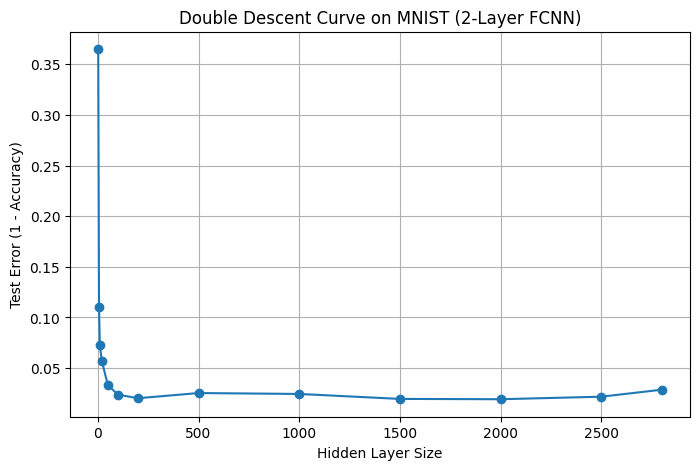

In [48]:
# Range of hidden layer sizes to simulate double descent
hidden_sizes = [2, 6, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000, 2500, 2800]
test_errors = []

for size in hidden_sizes:
    model = Sequential()
    model.add(Dense(size, activation='relu', input_shape=(784,)))
    model.add(Dense(size, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

    _, accuracy = model.evaluate(x_test, y_test, verbose=0)
    error = 1 - accuracy
    test_errors.append(error)
    print(f"Hidden Size: {size} → Test Accuracy: {accuracy:.4f} → Test Error: {error:.4f}")

    # Plot the Double Descent Curve
plt.figure(figsize=(8, 5))
plt.plot(hidden_sizes, test_errors, marker='o')
plt.title("Double Descent Curve on MNIST (2-Layer FCNN)")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Test Error (1 - Accuracy)")
plt.grid(True)
plt.show()

The plotted curve of test error against hidden layer size demonstrates the double descent pattern—an initial drop, a small rise, then another drop as model size grows.

**INSIGHTS**

* For very small hidden sizes (2–10), accuracy is low due to underfitting.

* Accuracy improves rapidly as hidden layer size increases to ~200 neurons.

* Beyond 200 neurons, performance fluctuates slightly, showing the double descent trend:

* Error decreases, then rises slightly (e.g., at 500–1000), and then falls again at larger capacities (1500–2000 neurons).

* This behavior aligns with the bias-variance tradeoff reinterpretation, where model capacity can reduce error again after the interpolation threshold.